# Convolutional neural networks: classifying CIFAR-10 images

A convolutional neural network (CNN) learns spatial patterns in images and uses the resulting responses to make predictions. Here we build a CNN that takes a color image as input and produces a score for each of ten object categories. Training adjusts the network's weights so that the correct label receives a higher score than the alternatives.

The exercise has three parts: define the network, compute its classification loss, and implement the training loop. Data loading and plotting code are provided. Complete the lines marked `TODO`, replacing each `...` with code, and run the cells in order.

In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)

## 1. Images and labels

CIFAR-10 contains 32 × 32 color images in ten categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. Each image is paired with an integer label from 0 to 9, indexing this list. The numbers identify categories; they do not describe an ordering or numerical distance between them. `ToTensor()` converts an image into a tensor, a multidimensional array, and scales its pixel intensities from 0–255 to 0–1.

PyTorch's convolution layers expect inputs with dimensions `[batch, channels, height, width]`. A batch of 64 CIFAR-10 images therefore has shape `[64, 3, 32, 32]`: each image has red, green, and blue intensity channels. The labels have shape `[64]`, with one integer per image.

We use a random subset of 10,000 of the 50,000 training images for training and the separate set of 10,000 test images for evaluation. `DataLoader` groups the images and labels into batches. Shuffling the training data changes which examples are grouped together on each pass through the dataset.

For display, `image.permute(1, 2, 0)` rearranges the tensor from `[channels, height, width]` to `[height, width, channels]`, the format expected by Matplotlib. The model uses the original channel-first format.

100%|██████████| 170M/170M [38:20<00:00, 74.1kB/s]   


Image batch: torch.Size([64, 3, 32, 32])
Label batch: torch.Size([64])


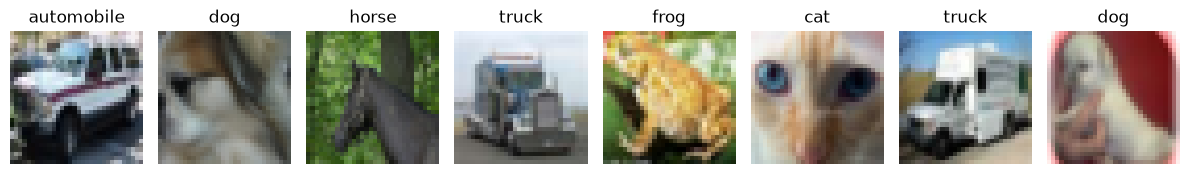

In [4]:
train_data = datasets.CIFAR10("data", train=True, download=True,
                            transform=transforms.ToTensor())
test_data = datasets.CIFAR10("data", train=False, download=True,
                           transform=transforms.ToTensor())

classes = train_data.classes

indices = torch.randperm(len(train_data))[:10000]
train_loader = DataLoader(Subset(train_data, indices), batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

images, labels = next(iter(train_loader))
print("Image batch:", images.shape)  # [batch, channels, height, width]
print("Label batch:", labels.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2.5))
for ax, image, label in zip(axes, images, labels):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. The network

### Convolution: local receptive fields and shared weights

A convolutional filter computes a weighted sum of the pixels in a small region of an image. For a 3 × 3 filter applied to an RGB image, this uses nine values from each of three color channels: 27 values multiplied by 27 learned weights, summed together with one learned bias. A filter combines information across all three channels to produce a single response. Applying the filter at successive positions produces a two-dimensional **feature map**: the response of that filter across the image.

The same weights are used at every position. This weight sharing allows a filter to respond to the same local pattern wherever it appears. Each response depends only on a small patch, its receptive field. Different filters have different weights and can learn sensitivity to different patterns. Their selectivity is learned from the classification task; we do not specify specific feature detectors in advance.

Our first convolution has three input channels and eight output channels. Each output channel is the feature map produced by one filter. With a step size (stride) of one and no added border pixels (padding), a 3 × 3 filter has 30 valid positions along each side of a 32 × 32 image. The output therefore has shape `[batch, 8, 30, 30]`.

The second and third convolutional layers operate on feature maps from the preceding layer. A filter spans all input channels: in the second layer, each filter has $8 \times 3 \times 3$ weights and one bias. It sums responses across both space and channels to produce one output feature map. We use 16 filters in the second layer and 32 in the third.

Stacking layers allows later responses to combine patterns detected by earlier layers. Before pooling, a unit in the first, second, or third layer depends on a 3 × 3, 5 × 5, or 7 × 7 region of the original image, respectively. The receptive field grows even though every filter uses a 3 × 3 kernel.

### ReLU, pooling, and the readout

**ReLU** applies $f(a)=\max(0,a)$ to each response. We apply it after each convolution. This rectification introduces a nonlinearity. Without nonlinear operations, a sequence of weighted sums would still be equivalent to a single affine transformation of the input.

**Max pooling** takes the largest response within each non-overlapping 2 × 2 region. We apply pooling once, after the third convolution and ReLU. It reduces each feature map from 26 × 26 to 13 × 13, retaining whether a filter responded strongly within a region while discarding its precise position inside that region. Pooling has no learned parameters.

**Flattening** arranges the pooled responses into a vector of length $32\times13\times13=5408$ for each image. It changes the arrangement of the values, not the values themselves. The batch dimension must remain separate.

The **linear readout** computes ten weighted sums of this vector, each with its own bias. These ten scores correspond to the ten object categories. The readout can combine responses from different filters and positions to distinguish categories.

| Operation | Output shape |
|---|---|
| Input | `[batch, 3, 32, 32]` |
| Convolution 1: 3 → 8 channels, then ReLU | `[batch, 8, 30, 30]` |
| Convolution 2: 8 → 16 channels, then ReLU | `[batch, 16, 28, 28]` |
| Convolution 3: 16 → 32 channels, then ReLU | `[batch, 32, 26, 26]` |
| Max pooling: 2 × 2 regions | `[batch, 32, 13, 13]` |
| Flatten | `[batch, 5408]` |
| Linear readout | `[batch, 10]` |

### Exercise A: define the model

In PyTorch, a model is a subclass of `nn.Module`. Its `__init__` method defines the layers and registers their parameters. Its `forward` method specifies how an input passes through those layers. Calling `model(images)` runs this forward computation.

Complete the three convolution definitions and the readout definition, then implement the operations in `forward` in the order shown above. Return the ten scores for each image.

Use `nn.Conv2d(in_channels, out_channels, kernel_size)` and `nn.Linear(in_features, out_features)` to define the learned layers. In the forward pass, apply the layers to `x`, use `torch.relu(x)` for rectification, and use `torch.flatten(x, start_dim=1)` to flatten all dimensions after the batch dimension.

In [6]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, (3, 3))
        self.conv2 = nn.Conv2d(8, 16, (3, 3))
        self.conv3 = nn.Conv2d(16, 32, (3, 3))
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.readout = nn.Linear(32 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        scores = self.readout(x)
        return scores

In [7]:
model = TinyCNN()
scores = model(images)
assert scores.shape == (len(images), 10), "We need ten scores per image."
print("Output shape:", scores.shape)
print("Scores for the first image:", scores[0].detach())

Output shape: torch.Size([64, 10])
Scores for the first image: tensor([ 0.0785, -0.0092,  0.0114,  0.0991,  0.0372, -0.0645,  0.0095, -0.0657,
        -0.0490, -0.0736])


The output contains one row per image and one column per category. At this stage, the weights are randomly initialized, so the scores do not yet reflect learned object classification.

The three convolutions and the readout contain the learned parameters. ReLU, pooling, and flattening apply fixed operations to the responses.

## 3. Classification loss

The network outputs ten real-valued scores, called **logits**. They can be positive or negative and do not need to sum to one. The predicted class is the index of the largest score.

To interpret scores as probabilities, softmax exponentiates each score and divides by the sum over all ten classes. If $s_k$ is the score for class $k$, then

$$p_k=\frac{\exp(s_k)}{\sum_{j=0}^{9}\exp(s_j)}.$$

For an image whose true label is $y$, the cross-entropy loss is

$$L=-\log p_y.$$

Assigning higher probability to the correct class reduces this loss. For example, $p_y=0.9$ gives a loss of about 0.11, whereas $p_y=0.1$ gives a loss of about 2.30. The loss varies continuously with the scores, allowing us to compute gradients even when the predicted label has not changed.

`nn.CrossEntropyLoss()` combines the probability conversion and negative log calculation in a numerically stable operation. It expects raw scores with shape `[batch, 10]` and integer labels with shape `[batch]`. Pass the scores directly; do not apply softmax first. By default, it returns the mean loss across the batch.

### Exercise B: compute the loss

Create the loss function using `nn.CrossEntropyLoss()`. Apply it to `scores` and `labels` to obtain a single scalar loss.

In [8]:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(scores, labels)
print(f"Initial batch loss: {loss.item():.3f}")

Initial batch loss: 2.318


A model assigning equal probability to all ten classes has a loss of $-\log(1/10)\approx2.30$. The initial loss should usually be near this value, though random weights need not produce exactly equal scores.

## 4. Training

Training changes the parameters of all three convolutions and the readout to reduce the loss. Let $\theta$ denote any learned weight or bias. For each batch, stochastic gradient descent (SGD) applies the update

$$\theta\leftarrow\theta-\eta\frac{\partial L}{\partial\theta},$$

where $\eta$ is the learning rate and $L$ is the mean loss for that batch. The derivative describes how a small change in the parameter affects the loss. Subtracting the gradient moves the parameter in the direction that locally reduces the loss; the learning rate determines the size of the step.

PyTorch records the operations in the forward computation. `loss.backward()` then uses the chain rule to compute the loss gradient for every learned parameter, including the convolutional filters. This is backpropagation. Computing gradients does not itself change the parameters; `optimizer.step()` performs the update.

Each batch requires the following operations:

1. Clear gradients from the previous batch with `optimizer.zero_grad()`. PyTorch accumulates gradients by default.
2. Compute the scores with `model(images)`.
3. Compute the loss with `loss_fn(scores, labels)`.
4. Compute gradients with `loss.backward()`.
5. Update the parameters with `optimizer.step()`.

### Exercise C: implement one training epoch

Complete these five operations inside `train_one_epoch`. An epoch is one pass through all training examples. The supplied code reports the mean loss per image across the epoch. `loss.item()` extracts the scalar value for this reporting; the tensor `loss` is used for backpropagation.

The next cell creates a fresh model and trains it for five epochs with a learning rate of 0.1. Individual batches can have higher or lower loss, but the average should generally decrease as the model learns.

In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        optimizer.zero_grad()
        scores = model.forward(images)
        loss = loss_fn(scores, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

Epoch 1: training loss = 2.281
Epoch 2: training loss = 2.117
Epoch 3: training loss = 1.997
Epoch 4: training loss = 1.901
Epoch 5: training loss = 1.795


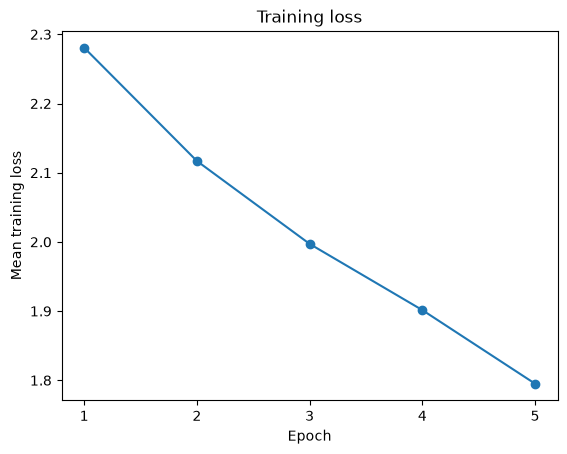

In [10]:
# Re-running this cell starts training again with fresh random weights.
torch.manual_seed(1)
model = TinyCNN()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

losses = []
for epoch in range(5):
    mean_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
    losses.append(mean_loss)
    print(f"Epoch {epoch + 1}: training loss = {mean_loss:.3f}")

plt.plot(range(1, 6), losses, "o-")
plt.xticks(range(1, 6))
plt.xlabel("Epoch")
plt.ylabel("Mean training loss")
plt.title("Training loss")
plt.show()

## 5. Evaluation on unseen images

Training loss measures performance on the examples used to update the weights. To assess whether the model has learned patterns that apply to other images, we evaluate it on the separate test set.

For each test image, `argmax(dim=1)` selects the column with the largest score, giving the predicted class. Test accuracy is the number of correct predictions divided by the total number of test images. Unlike cross-entropy, accuracy depends only on which score is largest, not on the relative confidence assigned to the classes.

The evaluation code below is complete. `model.eval()` sets evaluation mode, although it does not change the behavior of the layers used here. `torch.no_grad()` disables gradient tracking for these predictions. There is no backward pass or parameter update during evaluation.

Uniform random guessing gives 10% expected accuracy across these ten classes. These images vary in object pose, background, and lighting, so errors are expected after a short training run. Inspect both correct and incorrect predictions to see which categories the model confuses.

Test accuracy: 34.6%


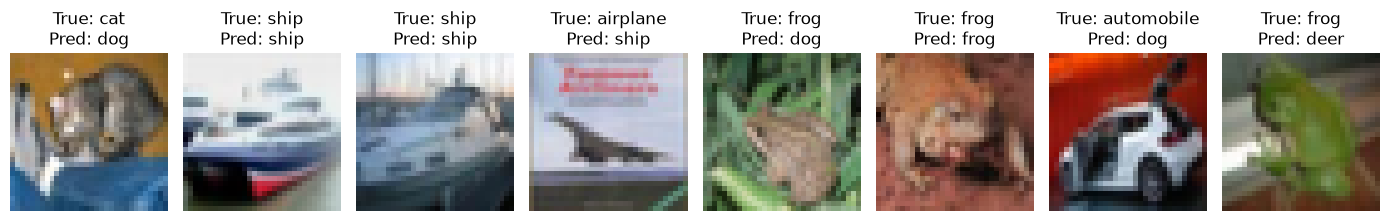

In [11]:
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
print(f"Test accuracy: {100 * correct / len(test_data):.1f}%")

images, labels = next(iter(test_loader))
with torch.no_grad():
    predictions = model(images[:8]).argmax(dim=1)

fig, axes = plt.subplots(1, 8, figsize=(14, 2.5))
for ax, image, label, prediction in zip(axes, images, labels, predictions):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"True: {classes[label.item()]}\nPred: {classes[prediction.item()]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Questions

1. Each filter in the first layer has 27 weights and one bias. How many weights and biases does one filter in the second layer have? Why does the number of convolutional parameters remain the same if the input image becomes larger? Would the linear readout defined here still accept the resulting responses?
2. What is retained by max pooling, and what spatial information is lost?
3. What happens to the parameters if `loss.backward()` runs but `optimizer.step()` is omitted? What happens if gradients are never cleared?
4. Could two models have the same classification accuracy but different cross-entropy losses? Explain using their scores for the correct class.
5. Why is a decrease in training loss insufficient evidence that the model will classify unseen images accurately?

## Responses

1. One filter in the second layer has 72 weights and one bias per filter. A filter has  fixed spatial size, regardless of the input image size. Every spatial location uses the same filter weights, but these weights are applied a different number of times for each image depending on the image size. No, the readout would not always accept the resulting image, since the readout expects 128 inputs per image, corresponding to a 32x32 image, but that would not work with any other size.
2. The maximum value takes the maximum value for each 2x2 region to create a resulting matrix scaled down by 2 on each dimension, which keeps where a given feature was directed most strongly in that 2x2 region. This is a more compact representation, but it discards specific localized information.
3. If `loss.backward()` runs but `optimizer.step()` does not, then the parameters never actually update, since the step function is what uses the gradients calculated in the backward function to update weights. If the gradients are never cleared, the gradients would accumulate by default and add add them to the previous.
4. Yes, they could. The accuracy cares about which class has the highest score. Therefore, two models may both predict the correct class, but one may be way higher confidence than another. In this case, the higher confidence model would have a lower cross-entropy loss, depsite having the same accuracy.
5. The model is just adapting to the images it has already seen and could be learning the specific patterns it picks up in those images, which would not necessarily be present in different images of the same entity. Like for example, the training data may have an image of a dog from the side and a cat from the front, while the eval data has the opposite. The model would pick up that the dog from the side is a dog and the cat from the front is a cat, but it may also pick up the feature that "animal standing to side" is a dog and "animal standing facing front" is a cat, so it would fail in the evaluation.